NEA - CDX, CHB, CHS, JPT, KOR

SEA - KHV, MYA, VNK

SWA - BEB, GIH, IN, ITU, NP, PJL, PT, STU

0. CDX shift
1. Why frequencies of base pairs is not continuous?
2. How we should deal with the 'distance' between genotypes?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'

In [4]:
from data import load_data, regions, popls

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]

# Basic counting

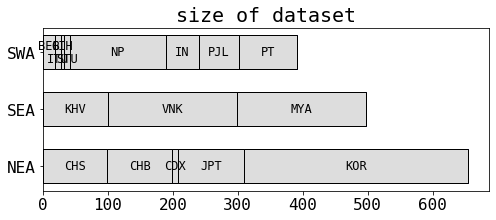

In [14]:
by_region = df['region'].value_counts().sort_index(key=lambda ser: ser.map(regions.index))
by_popl = df['popl'].value_counts().sort_index(key=lambda ser: ser.map(popls.index))
p2r = pd.Series({p: r for p, r in zip(df['popl'], df['region'])}).sort_index(key=lambda ser: ser.map(popls.index))
plt.figure(figsize=(8, 3))
plt.barh(by_region.index, by_region, height=0.6, color='white', edgecolor='blue')
for p in by_popl.index:
    r = p2r[p]
    left = by_popl[(by_popl.index.map(popls.index) < popls.index(p)) & (p2r == r)].sum()
    width = by_popl[p]
    plt.barh([r], [width], height=0.6, left=left, color='#dddddd', edgecolor='black')
    va = 'center'
    if p in ('BEB', 'GIH'):
        va = 'bottom'
    elif p in ('ITU', 'STU'):
        va = 'top'
    plt.text(left+width/2, r, p, fontsize=12, va=va, ha='center')
plt.title('size of dataset', fontsize=20)
plt.xticks(fontsize=16); plt.yticks(fontsize=16)
plt.show(); plt.close()

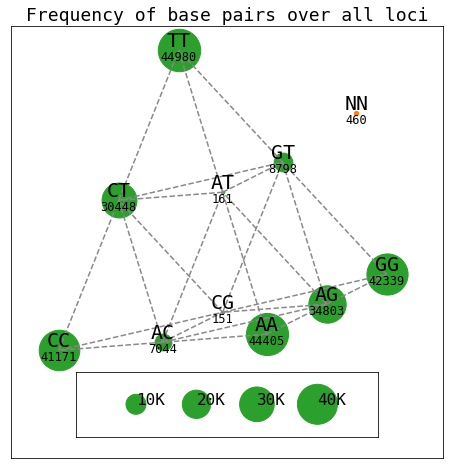

In [4]:
import itertools
bases = 'ACGT'
verts = np.array([[1., 1., 1.], [1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])
azim = 30; lat = 60
azim, lat = azim*(np.pi/180), lat*(np.pi/180)
radial = np.array([np.cos(lat)*np.cos(azim), np.cos(lat)*np.sin(azim), np.sin(lat)])
vertical = np.cross(radial, np.cross([0, 0, 1], radial))
vertical = vertical / np.linalg.norm(vertical)
horizontal = np.cross(vertical, radial)
verts = verts @ np.stack([horizontal, vertical]).T

fig = plt.figure(figsize=(10, 10))
ax = plt.axes([0.2, 0.2, 0.6, 0.6])
# fig, ax = plt.subplots(figsize=(10, 10))
for i, j in itertools.combinations_with_replacement(range(4), 2):
    vert_i, vert_j = verts[i], verts[j]
    vert = (vert_i + vert_j) / 2
    pair = f'{bases[i]}{bases[j]}'
    val = (df[genes] == pair).sum().sum()
    ax.scatter(*vert.reshape(-1, 1), s=val*4e-2, c='C2', zorder=0)
    ax.text(*vert, pair, fontsize=20, ha='center', va='bottom', zorder=100)
    ax.text(*vert, val, fontsize=12, ha='center', va='top', zorder=100)
    for k, l in itertools.combinations_with_replacement(range(4), 2):
        vert_other = (verts[k] + verts[l]) / 2
        if (i < k and j == l) or (i == k and j < l) or (i == l and j < k) or (i < l and j == k):
            ax.plot(*np.stack([vert, vert_other]).T, c='#888888', linestyle='--')

val = (df[genes] == 'NN').sum().sum()
ax.scatter(0.8, 0.8, s=val*4e-2, c='C1', transform=ax.transAxes)
ax.text(0.8, 0.8, 'NN', fontsize=20, ha='center', va='bottom', transform=ax.transAxes)
ax.text(0.8, 0.8, val, fontsize=12, ha='center', va='top', transform=ax.transAxes)
ax.set_xlim(-0.7, 1.1); ax.set_ylim(-1.2, 0.6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Frequency of base pairs over all loci', fontsize=18)

ax_sub = ax.inset_axes([0.15, 0.05, 0.7, 0.15])
ax_sub.set_xticks([]); ax_sub.set_yticks([])
ax_sub.scatter(np.arange(0.2, 1, 0.2), [0.5]*4, s=np.arange(1, 5, 1)*1e4*4e-2, c='C2', transform=ax_sub.transAxes)
for i in range(4):
    ax_sub.text(0.2*(i+1), 0.5, f'{i+1}0K', fontsize=16, transform=ax_sub.transAxes)
plt.show(); plt.close()

In [12]:
for i in range(1, df.shape[1]-2):
    cnt = set(df.iloc[:, i].unique())
    if 'NN' in cnt:
        cnt.remove('NN')
    # if len(cnt) != 3:
    #     print(df.columns[i], cnt, )
    cnt = set(''.join(cnt))
    if len(cnt) != 2:
        print(df.columns[i], cnt, )

rs3118378 {'C', 'A', 'G'}
rs2814778 {'T'}
rs7722456 {'C', 'T', 'A'}
rs10108270 {'C', 'T', 'A'}


In [4]:
from scipy.stats import chi2_contingency
import itertools

p_vals = []
for i1, var1 in enumerate(df.columns[1:-2]):
    for i2, var2 in enumerate(df.columns[1:-2]):
        if i1 >= i2:
            continue
        mask_notna = (df[[var1, var2]] != 'NN').all(axis=1)
        table = pd.crosstab(df.loc[mask_notna, var1], df.loc[mask_notna, var2])
        test_result = chi2_contingency(table)
        p_vals.append(test_result[1])
        # if test_result[1] < 0.05:
        #     print(i1, i2, test_result[1])
        #     print(table)

In [5]:
p_vals = np.array(p_vals)

# Catboost

In [135]:
from catboost import CatBoostClassifier, Pool
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

model = CatBoostClassifier()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])
X_train, X_test, y_train, y_test = train_test_split(df[genes].values, y, test_size=0.2, stratify=y, random_state=42)

model.fit(
    Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes),
    verbose=0
)
print(f'accuracy on training set: {np.mean(model.predict(X_train).ravel() == y_train):.4f}')
print(classification_report(y_test, model.predict(X_test).ravel(), digits=4))

accuracy on training set: 0.9789
              precision    recall  f1-score   support

           0     0.8529    0.8855    0.8689       131
           1     0.8085    0.7600    0.7835       100
           2     0.9494    0.9615    0.9554        78

    accuracy                         0.8641       309
   macro avg     0.8703    0.8690    0.8693       309
weighted avg     0.8629    0.8641    0.8631       309



In [7]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.cluster import DBSCAN

class DistFrom():
    def __init__(self, bases):
        self.bases = bases
    
    def __call__(self, X):
        return np.stack([np.linalg.norm(X - base, ord=1) for base in self.bases]).T

class BaseCount():
    def __init__(self, choices=None):
        if choices is None:
            choices = [0, 1, 2, 3]
        self.choices = choices

    def __call__(self, X):
        return np.stack([np.sum(X[..., i::4], axis=-1) for i in range(4)]).T[..., self.choices]

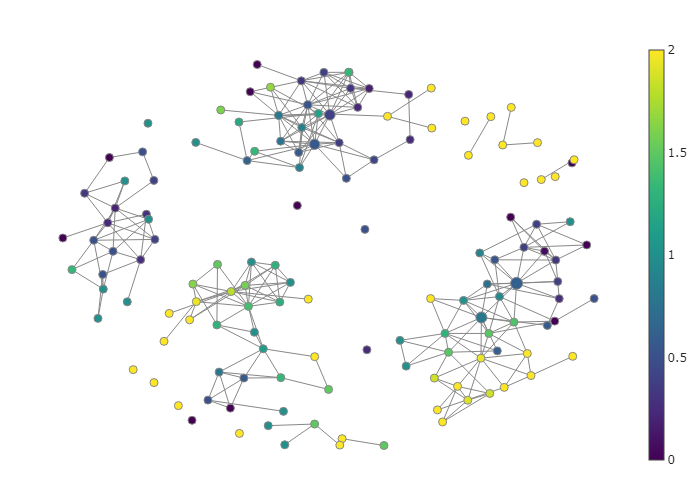

In [16]:
from sklearn.preprocessing import LabelEncoder

pipe = make_mapper_pipeline(
    filter_func=BaseCount(choices=[0, 1, 2, 3]),
    cover=CubicalCover(n_intervals=5, overlap_frac=0.111),
    clusterer=DBSCAN(
        metric='manhattan'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    df_chs.values,
    color_data=LabelEncoder().fit_transform(region)
)
fig.show(renderer='png')

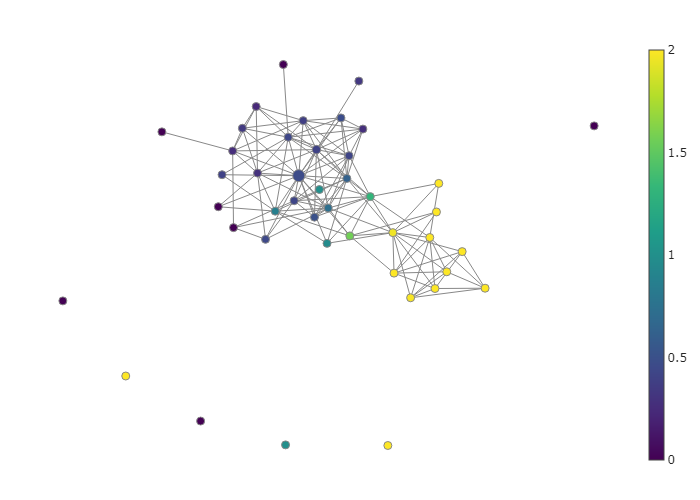

In [17]:
pipe = make_mapper_pipeline(
    filter_func=DistFrom(df_chs.values[[0, 500, 1000]]),
    cover=CubicalCover(n_intervals=8, overlap_frac=0.12),
    clusterer=DBSCAN(
        metric='manhattan'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    df_chs.values,
    color_data=LabelEncoder().fit_transform(region)
)
fig.show(renderer='png')